In [243]:
import re
import pandas as pd

CHAT_FILE = "kk.txt"        
with open(CHAT_FILE, "r", encoding="utf-8") as f:text = f.read()

pattern = r'(\d{1,2}/\d{1,2}/\d{4},\s\d{1,2}:\d{2}\s(?:am|pm))\s-\s([^:]+):\s([\s\S]*?)(?=\n\d{1,2}/\d{1,2}/\d{4},\s\d{1,2}:\d{2}\s(?:am|pm)\s-\s|\Z)'
matches = re.findall(pattern, text, flags=re.IGNORECASE)

print("Total Messages :", len(matches))
df = pd.DataFrame(matches,columns=["DateTime","User","Message"])

df["DateTime"] = pd.to_datetime(df["DateTime"],format="%d/%m/%Y, %I:%M %p")

df["Date"] = df["DateTime"].dt.date
df["Time"] = df["DateTime"].dt.time
df["Day"] = df["DateTime"].dt.day_name()
df["Hour"] = df["DateTime"].dt.hour

df.reset_index(drop=True, inplace=True)
df.head()

Total Messages : 725


,DateTime,User,Message,Date,Time,Day,Hour
0,2020-01-11 18:12:00,Karti,IMG-20200111-WA0058.jpg (file attached),2020-01-11,18:12:00,Saturday,18
1,2020-01-11 18:12:00,Karti,IMG-20200111-WA0057.jpg (file attached),2020-01-11,18:12:00,Saturday,18
2,2020-01-11 18:12:00,Karti,IMG-20200111-WA0049.jpg (file attached),2020-01-11,18:12:00,Saturday,18
3,2020-01-11 18:12:00,Karti,IMG-20200111-WA0056.jpg (file attached),2020-01-11,18:12:00,Saturday,18
4,2020-01-11 18:12:00,Karti,IMG-20200111-WA0055.jpg (file attached),2020-01-11,18:12:00,Saturday,18


In [244]:
df.to_csv("whatsapp_chat.csv", index=False)
print("CSV Saved")
print(df.shape)

CSV Saved
(725, 7)


In [245]:
flirt_keywords = ["love","luv","miss","baby","babe","dear","darling","sweet","cute","beautiful","handsome","hug","romantic","good night","good morning","take care","thinking of you",
    "❤️","❤","💕","💖","💞","💋","😘","😍","🥰","🙈","🙊","🤩","🥵","😚","🤣","😊","😍😍😍😍"]

In [246]:
def create_label(msg):
    msg = str(msg).lower()
    for word in flirt_keywords:
        if word.lower() in msg:
            return "Flirt"
    return "Normal"
df["Label"] = df["Message"].apply(create_label)
df.head()

,DateTime,User,Message,Date,Time,Day,Hour,Label
0,2020-01-11 18:12:00,Karti,IMG-20200111-WA0058.jpg (file attached),2020-01-11,18:12:00,Saturday,18,Normal
1,2020-01-11 18:12:00,Karti,IMG-20200111-WA0057.jpg (file attached),2020-01-11,18:12:00,Saturday,18,Normal
2,2020-01-11 18:12:00,Karti,IMG-20200111-WA0049.jpg (file attached),2020-01-11,18:12:00,Saturday,18,Normal
3,2020-01-11 18:12:00,Karti,IMG-20200111-WA0056.jpg (file attached),2020-01-11,18:12:00,Saturday,18,Normal
4,2020-01-11 18:12:00,Karti,IMG-20200111-WA0055.jpg (file attached),2020-01-11,18:12:00,Saturday,18,Normal


In [247]:
print(df["Label"].value_counts())

Label
Normal    662
Flirt      63
Name: count, dtype: int64


In [248]:
df.to_csv("flirting_rated.csv", index=False)
print("Training CSV Created Successfully")

Training CSV Created Successfully


In [249]:
import pandas as pd
df = pd.read_csv("flirting_rated.csv")
df = df.dropna(subset=["Message","Label"])
df.tail()

,DateTime,User,Message,Date,Time,Day,Hour,Label
720,2020-03-05 14:59:00,Vijay Murthy,Vera ena pana,2020-03-05,14:59:00,Thursday,14,Normal
721,2020-03-05 15:02:00,Vijay Murthy,9003225576,2020-03-05,15:02:00,Thursday,15,Normal
722,2020-03-05 15:02:00,Vijay Murthy,Idan metro srinivasan number,2020-03-05,15:02:00,Thursday,15,Normal
723,2020-03-05 15:02:00,Karti,Ok,2020-03-05,15:02:00,Thursday,15,Normal
724,2020-03-05 15:03:00,Vijay Murthy,Udanae call paniru\n,2020-03-05,15:03:00,Thursday,15,Normal


In [250]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["Target"] = encoder.fit_transform(df["Label"])
print(encoder.classes_)

['Flirt' 'Normal']


In [251]:
from sklearn.model_selection import train_test_split
X = df["Message"]
y = df["Target"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print(len(X_train),len(X_test))

580 145


In [252]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

count_nb = Pipeline([("vectorizer",CountVectorizer()),("classifier",MultinomialNB())])
count_nb.fit(X_train,y_train)
pred1 = count_nb.predict(X_test)
acc1 = accuracy_score(y_test,pred1)
print("CountVectorizer + Naive Bayes Accuracy :",acc1)

CountVectorizer + Naive Bayes Accuracy : 0.9103448275862069


In [253]:
from sklearn.linear_model import LogisticRegression
count_lr = Pipeline([("vectorizer",CountVectorizer()),("classifier",LogisticRegression(max_iter=1000))])
count_lr.fit(X_train,y_train)
pred2 = count_lr.predict(X_test)
acc2 = accuracy_score(y_test,pred2)
print("CountVectorizer + Logistic Regression Accuracy :",acc2)

CountVectorizer + Logistic Regression Accuracy : 0.9103448275862069


In [254]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_nb = Pipeline([("vectorizer",TfidfVectorizer()),("classifier",MultinomialNB())])
tfidf_nb.fit(X_train,y_train)
pred3 = tfidf_nb.predict(X_test)
acc3 = accuracy_score(y_test,pred3)
print("TF-IDF + Naive Bayes Accuracy :",acc3)

TF-IDF + Naive Bayes Accuracy : 0.9103448275862069


In [255]:
tfidf_lr = Pipeline([("vectorizer",TfidfVectorizer()),("classifier",LogisticRegression(max_iter=1000))])
tfidf_lr.fit(X_train,y_train)
pred4 = tfidf_lr.predict(X_test)
acc4 = accuracy_score(y_test,pred4)
print("TF-IDF + Logistic Regression Accuracy :",acc4)

TF-IDF + Logistic Regression Accuracy : 0.9103448275862069


In [256]:
results = pd.DataFrame({"Model":["Count + Naive Bayes","Count + Logistic Regression","TF-IDF + Naive Bayes","TF-IDF + Logistic Regression"],
    "Accuracy":[acc1,acc2,acc3,acc4]})

results = results.sort_values("Accuracy",ascending=False)
results

,Model,Accuracy
0,Count + Naive Bayes,0.910345
1,Count + Logistic Regression,0.910345
2,TF-IDF + Naive Bayes,0.910345
3,TF-IDF + Logistic Regression,0.910345


In [257]:
best_model = max([(acc1,count_nb),(acc2,count_lr),(acc3,tfidf_nb),(acc4,tfidf_lr)],key=lambda x:x[0])[1]
print(best_model)

Pipeline(steps=[('vectorizer', CountVectorizer()),
                ('classifier', MultinomialNB())])


In [258]:
df["Prediction"] = encoder.inverse_transform(best_model.predict(df["Message"]))
df[["User","Message","Prediction"]].head(60)

,User,Message,Prediction
0,Karti,IMG-20200111-WA0058.jpg (file attached),Normal
1,Karti,IMG-20200111-WA0057.jpg (file attached),Normal
2,Karti,IMG-20200111-WA0049.jpg (file attached),Normal
3,Karti,IMG-20200111-WA0056.jpg (file attached),Normal
4,Karti,IMG-20200111-WA0055.jpg (file attached),Normal
5,Karti,IMG-20200111-WA0054.jpg (file attached),Normal
6,Karti,Dp❣,Normal
7,Vijay Murthy,😇😇,Normal
8,Vijay Murthy,Enn phone again call attend pana mudila,Normal
9,Vijay Murthy,Iru naanae pandran,Normal


In [259]:
df.to_csv("Predicted_Whatsapp_Chat.csv",index=False)
print("Prediction File Saved")

Prediction File Saved


### Talkative Person


In [260]:
user_count = df["User"].value_counts()
print(user_count)

print()
print("Most Talkative :", user_count.idxmax())
print("Least Talkative :", user_count.idxmin())

User
Karti           384
Vijay Murthy    341
Name: count, dtype: int64

Most Talkative : Karti
Least Talkative : Vijay Murthy


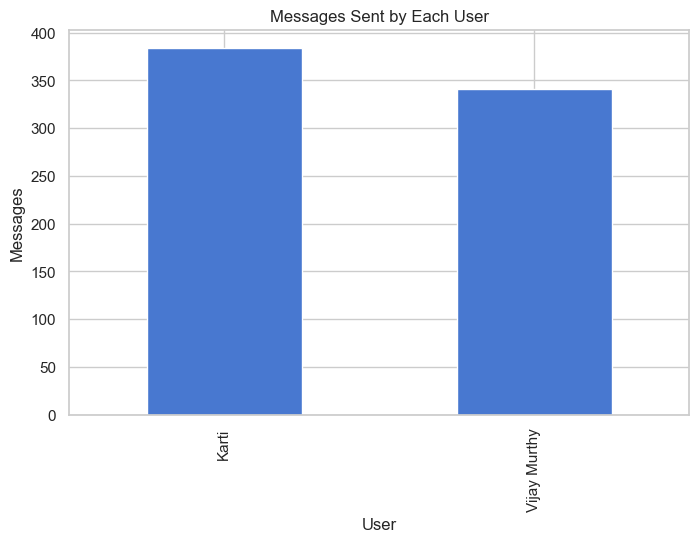

In [261]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
user_count.plot(kind="bar")
plt.title("Messages Sent by Each User")
plt.xlabel("User")
plt.ylabel("Messages")

plt.show()

### Most Active Day

In [262]:
day_count = df["Day"].value_counts()
print(day_count)
print()
print("Most Active Day :", day_count.idxmax())

Day
Thursday     177
Wednesday    138
Monday        97
Saturday      89
Sunday        89
Tuesday       82
Friday        53
Name: count, dtype: int64

Most Active Day : Thursday


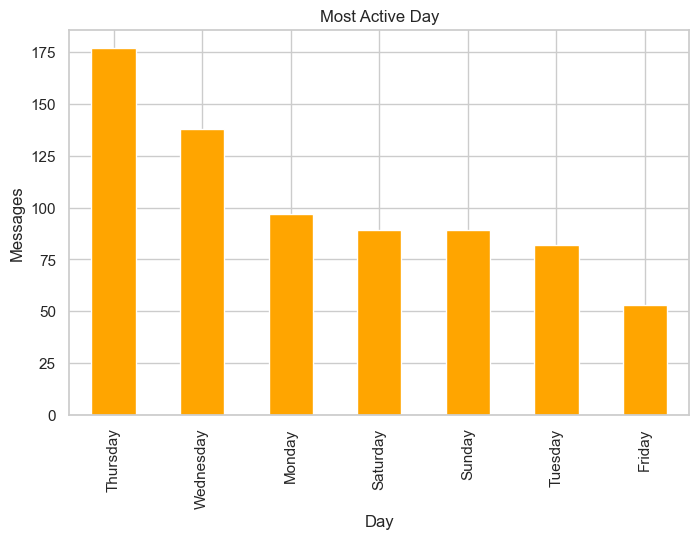

In [263]:
plt.figure(figsize=(8,5))
day_count.plot(kind="bar",color="orange")
plt.title("Most Active Day")
plt.xlabel("Day")
plt.ylabel("Messages")
plt.show()

### Most Active Hour

In [264]:
hour_count = df["Hour"].value_counts().sort_index()
print(hour_count)
print()
print("Most Active Hour :", hour_count.idxmax())

Hour
7       2
8       1
9      89
10     89
11     72
12     93
13     11
14    113
15     71
16     35
17     19
18     63
19     16
20     10
21     20
22     21
Name: count, dtype: int64

Most Active Hour : 14


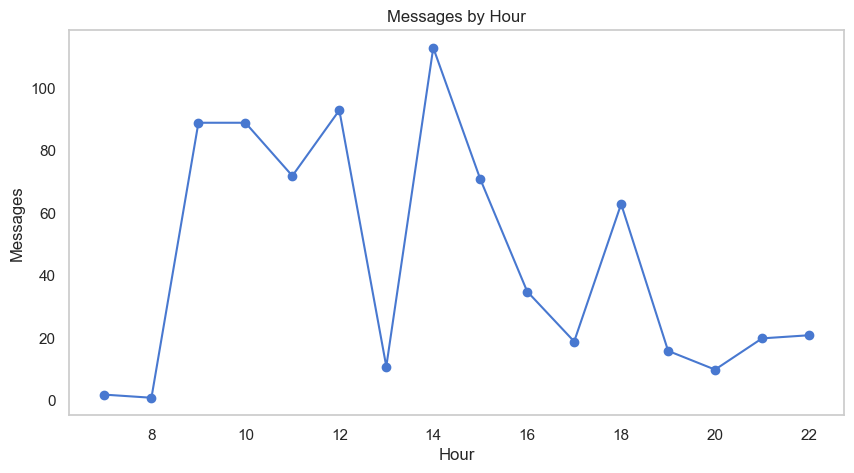

In [265]:
plt.figure(figsize=(10,5))
hour_count.plot(kind="line",marker="o")
plt.title("Messages by Hour")
plt.xlabel("Hour")
plt.ylabel("Messages")
plt.grid()
plt.show()

### Missed Calls

In [266]:
missed = df["Message"].str.contains("missed voice call|missed video call",case=False,na=False)

missed_df = df[missed]
print(missed_df[["User","Message"]])
print()
print("Total Missed Calls :",len(missed_df))

      User            Message
293  Karti  Missed voice call
364  Karti  Missed voice call

Total Missed Calls : 2


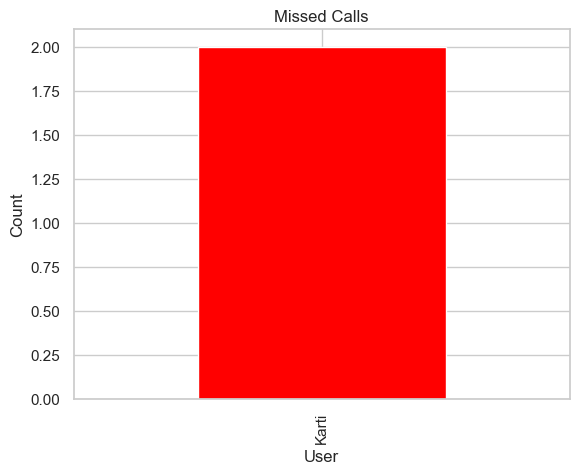

In [267]:
missed_user = missed_df.groupby("User").size()
if len(missed_user)>0:
    missed_user.plot(kind="bar",color="red")
    plt.title("Missed Calls")
    plt.ylabel("Count")
    plt.show()
else:
    print("No Missed Calls Found")

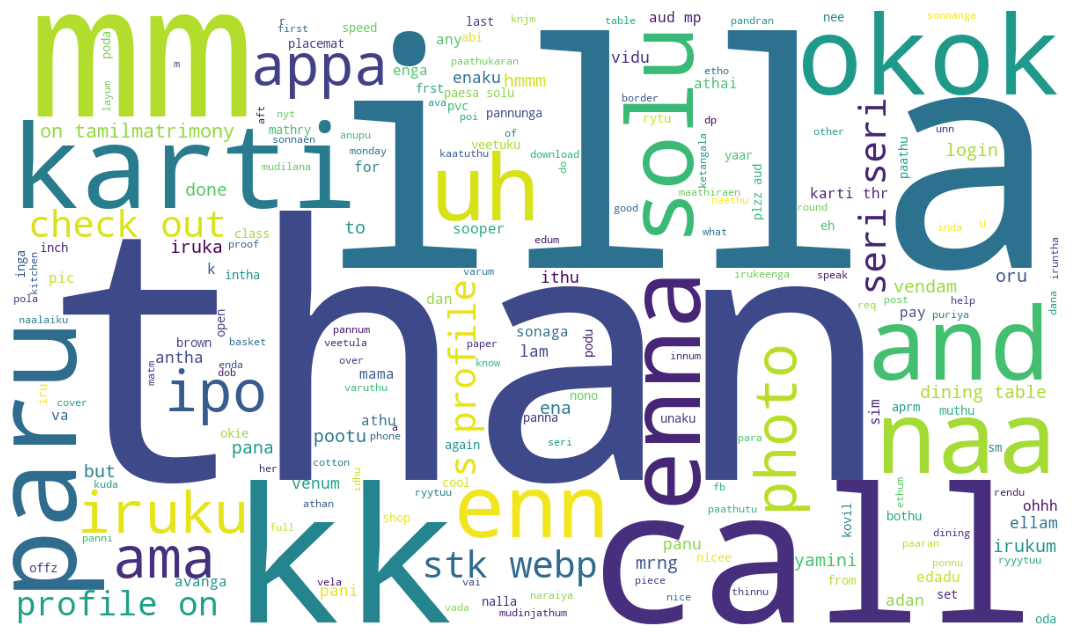

In [268]:
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["Message"].astype(str))

text = text.lower()
#cleaning unnecessary words

text = re.sub(r"http\S+"," ",text)
text = re.sub(r"\bimg\d+\b"," ",text)
text = re.sub(r"\bwa\d+\b"," ",text)
text = re.sub(r"\b\w+\.(jpg|jpeg|png|gif|webp|pdf|mp4|mp3|zip)\b"," ",text)
text = re.sub(r"\bfile\b"," ",text)
text = re.sub(r"\battached\b"," ",text)
text = re.sub(r"\bomitted\b"," ",text)
text = re.sub(r"\bmedia\b"," ",text)
text = re.sub(r"\bimage\b"," ",text)
text = re.sub(r"\bvideo\b"," ",text)
text = re.sub(r"\baudio\b"," ",text)
text = re.sub(r"\bdocument\b"," ",text)
text = re.sub(r"\bjpg\b"," ",text)
text = re.sub(r"\bimg\b"," ",text)
text = re.sub(r"\bthis message was deleted\b"," ",text)
text = re.sub(r"\bdeleted\b"," ",text)
text = re.sub(r"\d+"," ",text)
text = re.sub(r"[^a-zA-Z ]"," ",text)
text = re.sub(r"\s+"," ",text)

stopwords = {"ok","okay","yeah","yes","no","da","dei","di","ku","la","na","nu","ah","hmm","mmm","lol","bro","sir","pls","please","hai","hi"}
wordcloud = WordCloud(width=1200,height=700,background_color="white",stopwords=stopwords).generate(text)

plt.figure(figsize=(14,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

### top 20 words

In [269]:
from collections import Counter
import re
words = re.findall(r"\b[a-zA-Z]+\b",text.lower())
counter = Counter(words)
top20 = pd.DataFrame(counter.most_common(20),columns=["Word","Frequency"])
top20

,Word,Frequency
0,ok,32
1,than,20
2,la,18
3,illa,17
4,ku,17
5,karti,16
6,seri,16
7,call,14
8,nu,14
9,mm,14


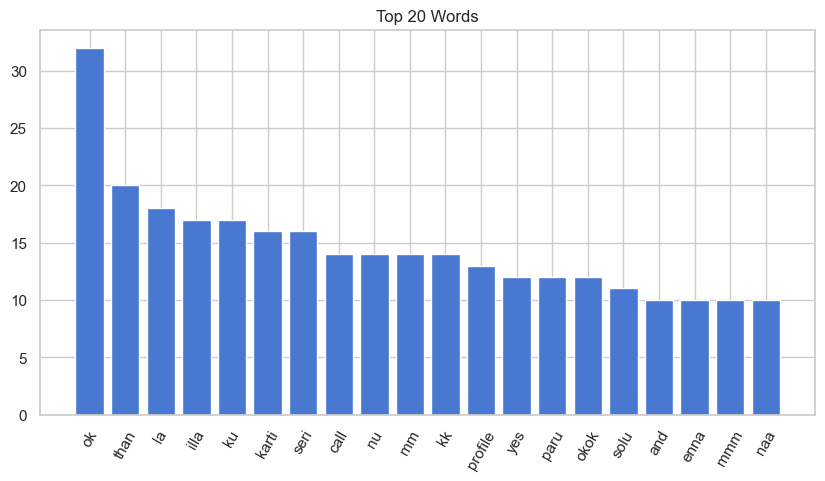

In [270]:
plt.figure(figsize=(10,5))
plt.bar(top20["Word"],top20["Frequency"])
plt.xticks(rotation=60)
plt.title("Top 20 Words")
plt.show()

## Flirt prediction count

In [271]:
prediction_count = df["Prediction"].value_counts()
print(prediction_count)

Prediction
Normal    708
Flirt      17
Name: count, dtype: int64


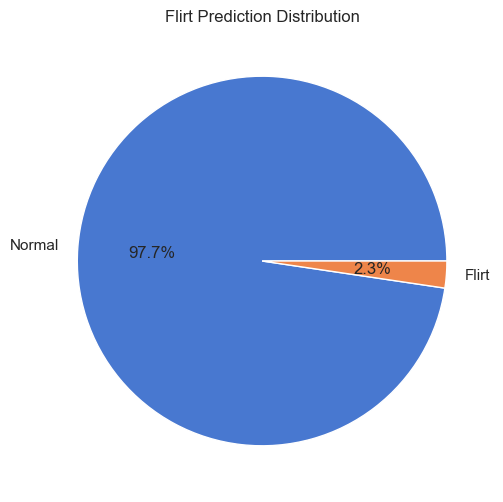

In [ ]:
prediction_count.plot(
    kind="pie",
    figsize=(6,6)
)

plt.ylabel("")

plt.title("Flirt Prediction Distribution")

plt.show()